In [ ]:
# Cell 1: Install and Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import random

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Cell 2: Define the Dataset
corpus = """machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance."""

print("Dataset loaded.")
print("Total characters:", len(corpus))

Dataset loaded.
Total characters: 819


In [ ]:
# Cell 3: Tokenize and Preprocess
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
print("Word Index (first 10):", list(tokenizer.word_index.items())[:10])

Vocabulary size: 87
Word Index (first 10): [('models', 1), ('sequence', 2), ('data', 3), ('in', 4), ('learning', 5), ('learn', 6), ('step', 7), ('networks', 8), ('time', 9), ('long', 10)]


In [ ]:
# Cell 4: Create Input-Output Sequence Pairs
input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

print("Total sequences:", len(input_sequences))
print("Max sequence length:", max_sequence_len)
print("Sample sequence:", input_sequences[5])

Total sequences: 95
Max sequence length: 9
Sample sequence: [ 0  0 19  5  1  6 20 21  3]


In [ ]:
# Cell 5: Split into Features (X) and Labels (Y)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95, 8)
y shape: (95, 87)


In [ ]:
# Cell 6: Build the LSTM Model
model = Sequential([
    Embedding(total_words, 64, input_length=max_sequence_len - 1),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 7: Train the Model
history = model.fit(X, y, epochs=100, verbose=1)

print("\nTraining Complete!")
print(f"Final Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Loss:     {history.history['loss'][-1]:.4f}")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0105 - loss: 4.4671
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0211 - loss: 4.4615    
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0526 - loss: 4.4556
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0526 - loss: 4.4492
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0526 - loss: 4.4358
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0526 - loss: 4.4197
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0526 - loss: 4.3743
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0526 - loss: 4.3305
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0526 - loss: 4.3046
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0526 - loss: 4.2838
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0526 - loss: 4.2535
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0632 

In [ ]:
# Cell 8: Generate New Sequences
def generate_text(seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Try different seed inputs
seeds = ["machine learning", "sequence models", "deep learning", "lstm uses"]

print("=" * 60)
print("GENERATED SEQUENCES (LSTM)")
print("=" * 60)
for seed in seeds:
    result = generate_text(seed, next_words=8)
    print(f"\nSeed: '{seed}'")
    print(f"Generated: {result}")

GENERATED SEQUENCES (LSTM)

Seed: 'machine learning'
Generated: machine learning models learn patterns from data data data forecasting

Seed: 'sequence models'
Generated: sequence models is useful in many applications intelligence intelligence intelligence

Seed: 'deep learning'
Generated: deep learning models learn sequences from data steps steps steps

Seed: 'lstm uses'
Generated: lstm uses is to control information flow intelligence intelligence intelligence


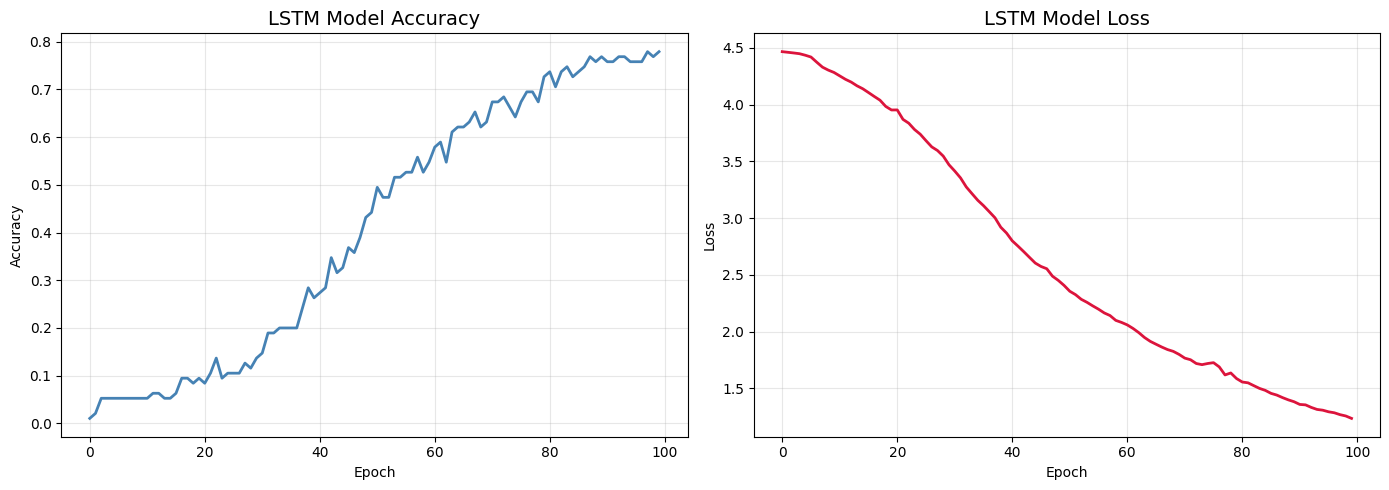

Plot saved.


In [ ]:
# Cell 9: Plot Training Accuracy and Loss
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], color='steelblue', linewidth=2)
axes[0].set_title('LSTM Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], color='crimson', linewidth=2)
axes[1].set_title('LSTM Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150)
plt.show()
print("Plot saved.")

In [ ]:
# Cell 10: Import Libraries for Transformer
import tensorflow as tf
from tensorflow.keras.layers import (Layer, Dense, Dropout, Embedding,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D)
from tensorflow.keras.models import Model
import numpy as np

print("Libraries loaded for Transformer.")

Libraries loaded for Transformer.


In [ ]:
# Cell 11: Reuse Dataset and Tokenizer from Component I
# (Run this only if running Component II independently)

corpus = """machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance."""

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer_t = Tokenizer()
tokenizer_t.fit_on_texts([corpus])
total_words_t = len(tokenizer_t.word_index) + 1

input_sequences_t = []
for line in corpus.split('\n'):
    token_list = tokenizer_t.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_t.append(token_list[:i+1])

max_seq_len_t = max(len(x) for x in input_sequences_t)
input_sequences_t = np.array(pad_sequences(input_sequences_t, maxlen=max_seq_len_t, padding='pre'))

X_t = input_sequences_t[:, :-1]
y_t = input_sequences_t[:, -1]
y_t = tf.keras.utils.to_categorical(y_t, num_classes=total_words_t)

print("Dataset ready for Transformer.")
print("Vocab size:", total_words_t, "| Max seq len:", max_seq_len_t)

Dataset ready for Transformer.
Vocab size: 87 | Max seq len: 9


In [ ]:
# Cell 12: Positional Encoding
class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

        # Compute positional encoding matrix
        positions = np.arange(max_len)[:, np.newaxis]
        dims = np.arange(d_model)[np.newaxis, :]
        angles = positions / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))

        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])

        self.pos_encoding = tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

print("PositionalEncoding layer defined.")

PositionalEncoding layer defined.


In [ ]:
# Cell 13: Transformer Encoder Block
class TransformerBlock(Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attention = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_output = self.attention(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

print("TransformerBlock layer defined.")

TransformerBlock layer defined.


In [ ]:
# Cell 14: Build the Transformer Model
d_model = 64
num_heads = 4
ff_dim = 128
dropout_rate = 0.1
seq_len = max_seq_len_t - 1

# Input
inputs = tf.keras.Input(shape=(seq_len,))

# Embedding + Positional Encoding
x = Embedding(total_words_t, d_model)(inputs)
x = PositionalEncoding(max_len=seq_len, d_model=d_model)(x)

# Transformer Blocks
x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x)
x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x)

# Output head
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
outputs = Dense(total_words_t, activation='softmax')(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 8, 64)          │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 8, 64)          │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 8, 64)          │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 8, 64)          │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 87)             │         5,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,167 (305.34 KB)

 Trainable params: 78,167 (305.34 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 15: Train the Transformer Model
history_t = transformer_model.fit(X_t, y_t, epochs=100, verbose=1)

print("\nTransformer Training Complete!")
print(f"Final Accuracy: {history_t.history['accuracy'][-1]:.4f}")
print(f"Final Loss:     {history_t.history['loss'][-1]:.4f}")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.0000e+00 - loss: 4.8403
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0211 - loss: 4.5586    
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.4417
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0632 - loss: 4.4251
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.3963
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.3942
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0316 - loss: 4.3735
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.3580
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.3089
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0421 - loss: 4.3352
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0421 - loss: 4.2713
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.06

In [ ]:
# Cell 16: Generate Sequences using Transformer
def generate_text_transformer(seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer_t.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len_t - 1, padding='pre')
        predicted_probs = transformer_model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)
        output_word = ""
        for word, index in tokenizer_t.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Test with seed inputs
seeds = ["machine learning", "sequence models", "deep learning", "generative models"]

print("=" * 60)
print("GENERATED SEQUENCES (TRANSFORMER)")
print("=" * 60)
for seed in seeds:
    result = generate_text_transformer(seed, next_words=8)
    print(f"\nSeed: '{seed}'")
    print(f"Generated: {result}")

GENERATED SEQUENCES (TRANSFORMER)

Seed: 'machine learning'
Generated: machine learning models learn patterns from data step by step

Seed: 'sequence models'
Generated: sequence models process data step by step by step by

Seed: 'deep learning'
Generated: deep learning improves sequence modeling performance performance performance sentence sentence

Seed: 'generative models'
Generated: generative models learn probability distributions distributions step by step by


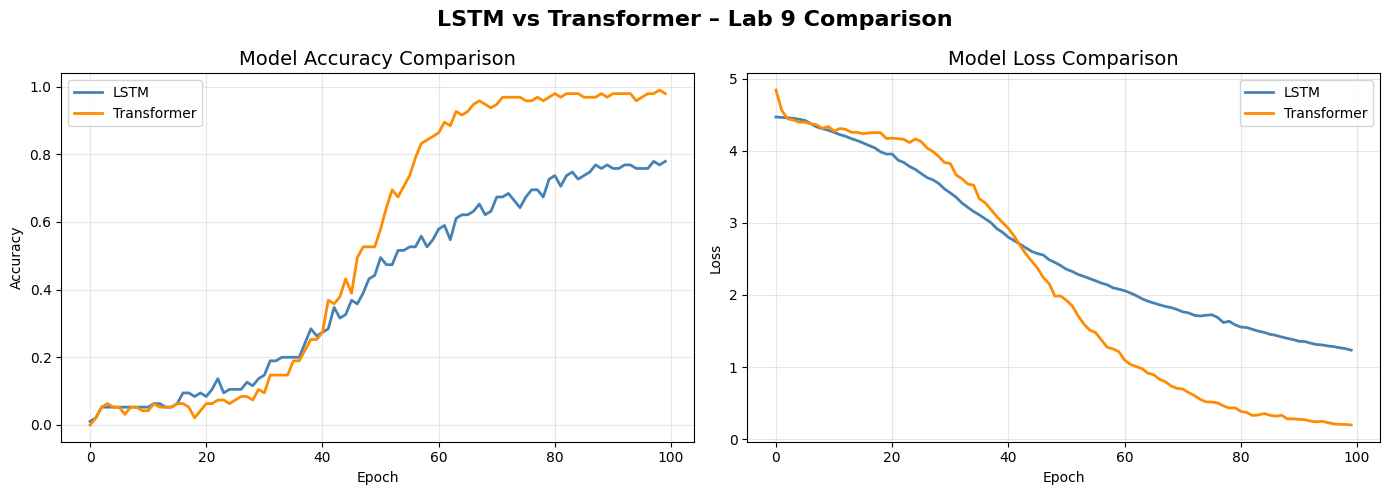

Comparison plot saved.


In [ ]:
# Cell 17: Side-by-Side Comparison Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='LSTM', color='steelblue', linewidth=2)
axes[0].plot(history_t.history['accuracy'], label='Transformer', color='darkorange', linewidth=2)
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='LSTM', color='steelblue', linewidth=2)
axes[1].plot(history_t.history['loss'], label='Transformer', color='darkorange', linewidth=2)
axes[1].set_title('Model Loss Comparison', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM vs Transformer – Lab 9 Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150)
plt.show()
print("Comparison plot saved.")